In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def normalize_channels(image):
    image = image.copy().transpose(1, 2, 0)
    image = np.abs(image)
    for channel in range(image.shape[2]):
        max_value = image[..., channel].max()
        if max_value > 0:
            image[..., channel] /= max_value
    return image

In [3]:
base_dir = "."
model_name = "convnext"
method_name = "NoiseTunnel_Saliency"
im_num = 5

In [4]:
exp = np.load(f"{base_dir}/attribution_maps/{model_name}/{method_name}/image_{im_num}.npy")
im = normalize_channels(exp)

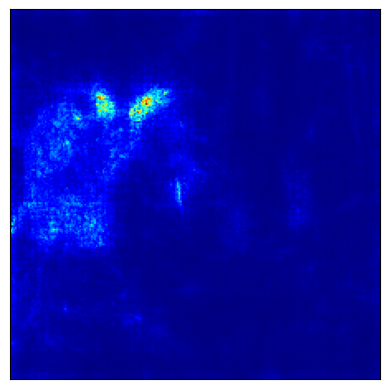

In [5]:
plt.imshow(im.mean(axis=2), cmap="jet")
plt.xticks([])
plt.yticks([])
plt.show()

In [6]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def unnormalize(img):
    return np.clip((img * std) + mean, 0, 1)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

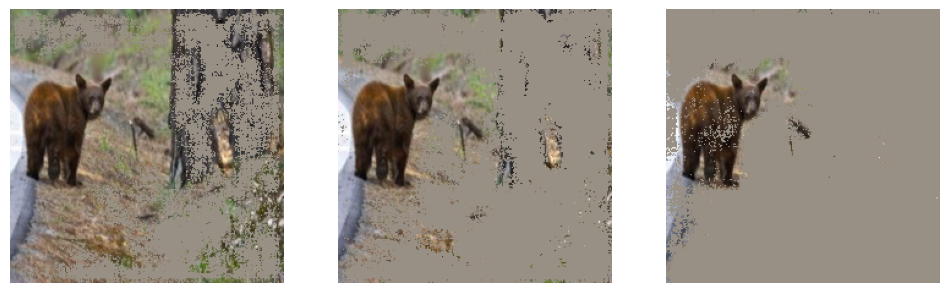

In [8]:
plt.figure(figsize=(12,4))
p = 50
plt.subplot(1,3,1)
exp = np.load(f"{base_dir}/perturbed_images/{model_name}/{method_name}/{p}/pEMI_{im_num}.npy")
exp = exp.transpose(1,2,0)
exp = unnormalize(exp)
plt.imshow(exp)
plt.axis('off')

plt.subplot(1,3,2)
p = 75
exp = np.load(f"{base_dir}/perturbed_images/{model_name}/{method_name}/{p}/pEMI_{im_num}.npy")
exp = exp.transpose(1,2,0)
exp = unnormalize(exp)
plt.imshow(exp)
plt.axis('off')

plt.subplot(1,3,3)
p = 90
exp = np.load(f"{base_dir}/perturbed_images/{model_name}/{method_name}/{p}/pEMI_{im_num}.npy")
exp = exp.transpose(1,2,0)
exp = unnormalize(exp)
plt.imshow(exp)
plt.axis('off')